In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pickle
import scienceplots

plt.style.use(['science','no-latex', 'notebook'])
colors = ["#00BBF9", "#CC2836", "#F3A712","#3eb690","#A05496","#114b5f"]
markers = ['o-','s-','^-']
#mpl.rcParams.update(mpl.rcParamsDefault)

In [28]:
def compute_IGs(imbalances):    
    n_indep_realizations = imbalances.shape[0]
    n_eps = imbalances.shape[1]
    
    IGs_vs_alpha = 100*(imbalances[:,:,0,np.newaxis]-imbalances) / imbalances[:,:,0,np.newaxis]
    alphas_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[np.arange(n_eps),alphas_max]
    errors = IGs_vs_alpha.std(axis=0)[np.arange(n_eps),alphas_max] / np.sqrt(n_indep_realizations)
    
    return IGs, errors

### Lorenz 96, all coordinates

In [47]:
seeds = np.arange(0.,31)
alphas = np.linspace(0.,1.5,300)
taus_forward = np.array([1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100, 150, 200])
taus_backward = -np.flip(taus_forward)
taus = np.append(taus_backward,taus_forward)

# X and Y
info_imbalances_X_to_Y = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_X = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_X_to_Y_obs = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_X_obs = np.zeros((len(seeds),len(taus),len(alphas)))
for i_seed, seed in enumerate(seeds):
    _, info_imbalances_X_to_Y[i_seed], info_imbalances_Y_to_X[i_seed] = pickle.load(open(f"./ig_scripts/pickles/XY_seed{i_seed}.p","rb"))
    _, info_imbalances_X_to_Y_obs[i_seed], info_imbalances_Y_to_X_obs[i_seed] = pickle.load(open(f"./ig_scripts/pickles_noZ/XY_seed{i_seed}.p","rb"))
IGs_X_to_Y, errors_X_to_Y = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, errors_Y_to_X = compute_IGs(info_imbalances_Y_to_X)
IGs_X_to_Y_obs, errors_X_to_Y_obs = compute_IGs(info_imbalances_X_to_Y_obs)
IGs_Y_to_X_obs, errors_Y_to_X_obs = compute_IGs(info_imbalances_Y_to_X_obs)

# Z and Y
info_imbalances_Z_to_Y = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_Z = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Z_to_Y_obs = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_Z_obs = np.zeros((len(seeds),len(taus),len(alphas)))
for i_seed, seed in enumerate(seeds):
    _, info_imbalances_Z_to_Y[i_seed], info_imbalances_Y_to_Z[i_seed] = pickle.load(open(f"./ig_scripts/pickles/ZY_seed{i_seed}.p","rb"))
    _, info_imbalances_Z_to_Y_obs[i_seed], info_imbalances_Y_to_Z_obs[i_seed] = pickle.load(open(f"./ig_scripts/pickles_noZ/ZY_seed{i_seed}.p","rb"))
IGs_Z_to_Y, errors_Z_to_Y = compute_IGs(info_imbalances_Z_to_Y)
IGs_Y_to_Z, errors_Y_to_Z = compute_IGs(info_imbalances_Y_to_Z)
IGs_Z_to_Y_obs, errors_Z_to_Y_obs = compute_IGs(info_imbalances_Z_to_Y_obs)
IGs_Y_to_Z_obs, errors_Y_to_Z_obs = compute_IGs(info_imbalances_Y_to_Z_obs)

# Z and X
info_imbalances_Z_to_X = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_X_to_Z = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Z_to_X_obs = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_X_to_Z_obs = np.zeros((len(seeds),len(taus),len(alphas)))
for i_seed, seed in enumerate(seeds):
    _, info_imbalances_Z_to_X[i_seed], info_imbalances_X_to_Z[i_seed] = pickle.load(open(f"./ig_scripts/pickles/ZX_seed{i_seed}.p","rb"))
    _, info_imbalances_Z_to_X_obs[i_seed], info_imbalances_X_to_Z_obs[i_seed] = pickle.load(open(f"./ig_scripts/pickles_noZ/ZX_seed{i_seed}.p","rb"))
IGs_Z_to_X, errors_Z_to_X = compute_IGs(info_imbalances_Z_to_X)
IGs_X_to_Z, errors_X_to_Z = compute_IGs(info_imbalances_X_to_Z)
IGs_Z_to_X_obs, errors_Z_to_X_obs = compute_IGs(info_imbalances_Z_to_X_obs)
IGs_X_to_Z_obs, errors_X_to_Z_obs = compute_IGs(info_imbalances_X_to_Z_obs)

### plots

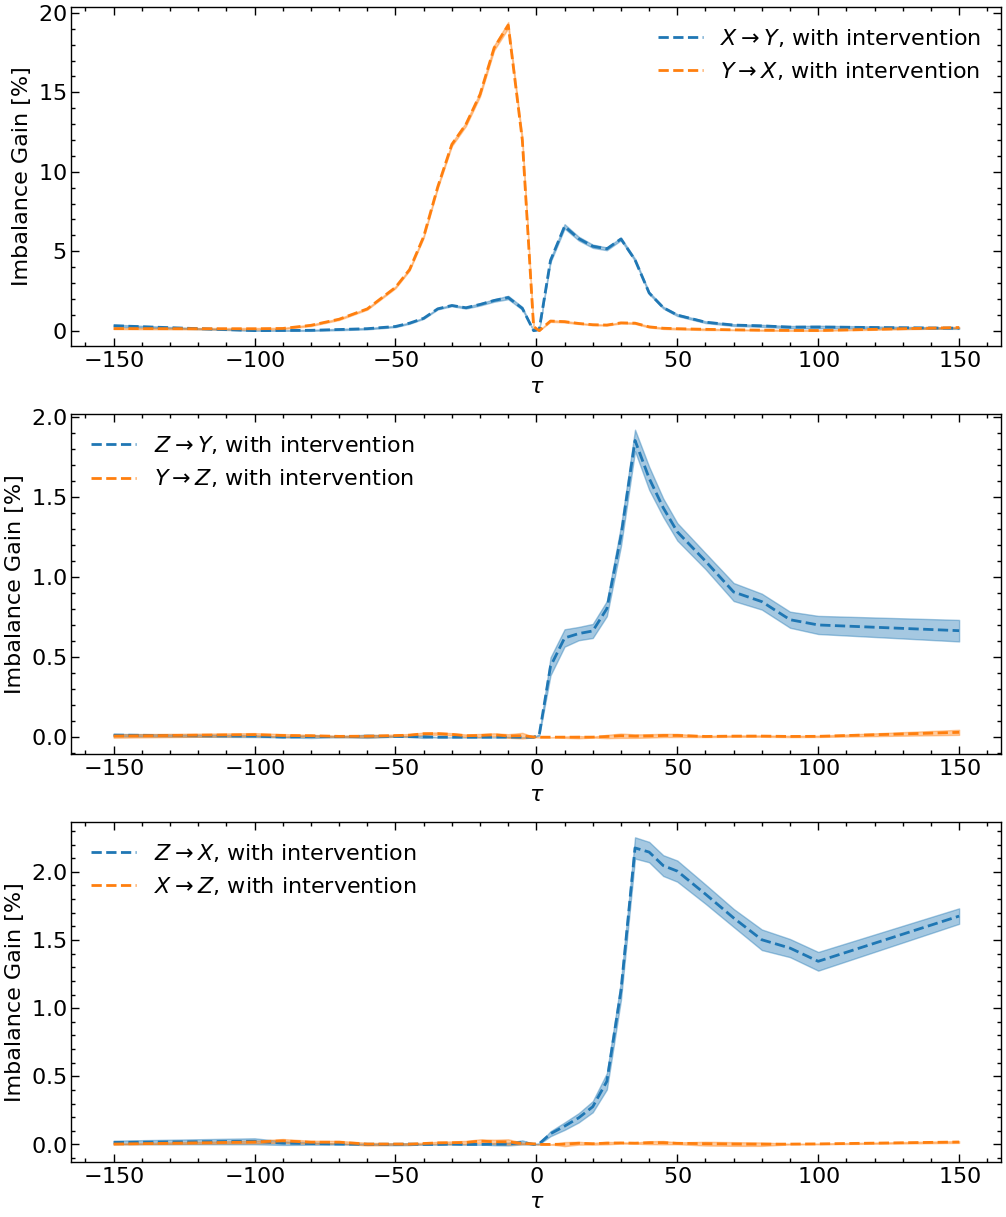

In [48]:
fig, ax = plt.subplots(3,1,figsize=(12,15))
n_skip = 1

############################### X and Y ###############################
ax[0].plot(taus[n_skip:-n_skip], IGs_X_to_Y[n_skip:-n_skip], '--', color="tab:blue", label="$X\\rightarrow Y$, with intervention")
ax[0].plot(taus[n_skip:-n_skip], IGs_Y_to_X[n_skip:-n_skip], '--', color="tab:orange", label="$Y\\rightarrow X$, with intervention")
ax[0].fill_between(taus[n_skip:-n_skip], IGs_X_to_Y[n_skip:-n_skip]-errors_X_to_Y[n_skip:-n_skip], IGs_X_to_Y[n_skip:-n_skip]+errors_X_to_Y[n_skip:-n_skip],
                   color="tab:blue", alpha=0.3)
ax[0].fill_between(taus[n_skip:-n_skip], IGs_Y_to_X[n_skip:-n_skip]-errors_Y_to_X[n_skip:-n_skip], IGs_Y_to_X[n_skip:-n_skip]+errors_Y_to_X[n_skip:-n_skip],
                   color="tab:orange", alpha=0.3)
ax[0].plot(taus[n_skip:-n_skip], IGs_X_to_Y_obs[n_skip:-n_skip], '-', color="tab:blue", label="$X\\rightarrow Y$, observational")
ax[0].plot(taus[n_skip:-n_skip], IGs_Y_to_X_obs[n_skip:-n_skip], '-', color="tab:orange", label="$Y\\rightarrow X$, observational")
ax[0].fill_between(taus[n_skip:-n_skip], IGs_X_to_Y_obs[n_skip:-n_skip]-errors_X_to_Y_obs[n_skip:-n_skip], 
                    IGs_X_to_Y_obs[n_skip:-n_skip]+errors_X_to_Y_obs[n_skip:-n_skip], color="tab:blue", alpha=0.3)
ax[0].fill_between(taus[n_skip:-n_skip], IGs_Y_to_X_obs[n_skip:-n_skip]-errors_Y_to_X_obs[n_skip:-n_skip], 
                    IGs_Y_to_X_obs[n_skip:-n_skip]+errors_Y_to_X_obs[n_skip:-n_skip], color="tab:orange", alpha=0.3)
ax[0].set(xlabel="$\\tau$", ylabel="Imbalance Gain [%]")
ax[0].legend()

############################### Z and Y ###############################
ax[1].plot(taus[n_skip:-n_skip], IGs_Z_to_Y[n_skip:-n_skip], '--', color="tab:blue", label="$Z\\rightarrow Y$, with intervention")
ax[1].plot(taus[n_skip:-n_skip], IGs_Y_to_Z[n_skip:-n_skip], '--', color="tab:orange", label="$Y\\rightarrow Z$, with intervention")
ax[1].fill_between(taus[n_skip:-n_skip], IGs_Z_to_Y[n_skip:-n_skip]-errors_Z_to_Y[n_skip:-n_skip], IGs_Z_to_Y[n_skip:-n_skip]+errors_Z_to_Y[n_skip:-n_skip],
                   color="tab:blue", alpha=0.3)
ax[1].fill_between(taus[n_skip:-n_skip], IGs_Y_to_Z[n_skip:-n_skip]-errors_Y_to_Z[n_skip:-n_skip], IGs_Y_to_Z[n_skip:-n_skip]+errors_Y_to_Z[n_skip:-n_skip],
                   color="tab:orange", alpha=0.3)
ax[1].plot(taus[n_skip:-n_skip], IGs_Z_to_Y_obs[n_skip:-n_skip], '--', color="tab:blue", label="$Z\\rightarrow Y$, observational")
ax[1].plot(taus[n_skip:-n_skip], IGs_Y_to_Z_obs[n_skip:-n_skip], '--', color="tab:orange", label="$Y\\rightarrow Z$, observational")
ax[1].fill_between(taus[n_skip:-n_skip], IGs_Z_to_Y_obs[n_skip:-n_skip]-errors_Z_to_Y_obs[n_skip:-n_skip], 
                   IGs_Z_to_Y_obs[n_skip:-n_skip]+errors_Z_to_Y_obs[n_skip:-n_skip], color="tab:blue", alpha=0.3)
ax[1].fill_between(taus[n_skip:-n_skip], IGs_Y_to_Z_obs[n_skip:-n_skip]-errors_Y_to_Z_obs[n_skip:-n_skip], 
                   IGs_Y_to_Z_obs[n_skip:-n_skip]+errors_Y_to_Z_obs[n_skip:-n_skip], color="tab:orange", alpha=0.3)
ax[1].set(xlabel="$\\tau$", ylabel="Imbalance Gain [%]")
ax[1].legend()

############################### Z and X ###############################
ax[2].plot(taus[n_skip:-n_skip], IGs_Z_to_X[n_skip:-n_skip], '--', color="tab:blue", label="$Z\\rightarrow X$, with intervention")
ax[2].plot(taus[n_skip:-n_skip], IGs_X_to_Z[n_skip:-n_skip], '--', color="tab:orange", label="$X\\rightarrow Z$, with intervention")
ax[2].fill_between(taus[n_skip:-n_skip], IGs_Z_to_X[n_skip:-n_skip]-errors_Z_to_X[n_skip:-n_skip], IGs_Z_to_X[n_skip:-n_skip]+errors_Z_to_X[n_skip:-n_skip],
                   color="tab:blue", alpha=0.3)
ax[2].fill_between(taus[n_skip:-n_skip], IGs_X_to_Z[n_skip:-n_skip]-errors_X_to_Z[n_skip:-n_skip], IGs_X_to_Z[n_skip:-n_skip]+errors_X_to_Z[n_skip:-n_skip],
                   color="tab:orange", alpha=0.3)
ax[2].plot(taus[n_skip:-n_skip], IGs_Z_to_X_obs[n_skip:-n_skip], '--', color="tab:blue", label="$Z\\rightarrow X$, observational")
ax[2].plot(taus[n_skip:-n_skip], IGs_X_to_Z_obs[n_skip:-n_skip], '--', color="tab:orange", label="$X\\rightarrow Z$, observational")
ax[2].fill_between(taus[n_skip:-n_skip], IGs_Z_to_X_obs[n_skip:-n_skip]-errors_Z_to_X_obs[n_skip:-n_skip], 
                   IGs_Z_to_X_obs[n_skip:-n_skip]+errors_Z_to_X_obs[n_skip:-n_skip], color="tab:blue", alpha=0.3)
ax[2].fill_between(taus[n_skip:-n_skip], IGs_X_to_Z_obs[n_skip:-n_skip]-errors_X_to_Z_obs[n_skip:-n_skip], 
                   IGs_X_to_Z_obs[n_skip:-n_skip]+errors_X_to_Z_obs[n_skip:-n_skip], color="tab:orange", alpha=0.3)
ax[2].set(xlabel="$\\tau$", ylabel="Imbalance Gain [%]")
ax[2].legend()

#plt.savefig("./figures/eps_zx=3.pdf", dpi=300)
plt.show()